# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

### ✦ My Analysis
*Enviornment Setup*

Powershell command
* conda create -n ml_assignment_env python=3.10
* conda activate ml_assignment_env
* conda install numpy==1.26.4 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2
* pip install pillow==11.1.0 tensorflow==2.18.0 keras==3.8.0 sklearn==1.6.1

In [39]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [78]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from keras import layers

In [41]:
import warnings
warnings.filterwarnings(action='ignore')

Load the dataset.

In [42]:
# Load and unzip the dataset
# Change directory
os.chdir("d:\\Projects\\GitHub\\MLAssignment\\data")

# Verify current directory
dataset_path = os.getcwd()

# Load dataset
dataset = keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(128, 128),   # resize images
    batch_size=32            # number of images per batch
)

# Check class names
print(dataset.class_names)




Found 7625 files belonging to 7 classes.
['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [43]:
# Create a function to load the raw images
def load_raw_images_dataset(path, batch_size=32):
    dataset = keras.utils.image_dataset_from_directory(
        path,        
        batch_size=batch_size
    )
    # Store class names before mapping 
    class_names = dataset.class_names
    
    #Normalize pixel values to [0, 1]
    dataset=dataset.map(lambda x, y: (x/255.0, y))
    return dataset, class_names


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [44]:
# Get the images and their labels
dataset, class_names = load_raw_images_dataset(path=dataset_path)

print("Length of DataSet:", len(dataset))
print("Number of Classes:", len(class_names))


for images, labels in dataset.take(1):
    print("Image Shape:", images[0].shape)
    print("First Label:", labels[0].numpy(), "→", class_names[labels[0]])
    

Found 7625 files belonging to 7 classes.
Length of DataSet: 239
Number of Classes: 7
Image Shape: (256, 256, 3)
First Label: 4 → Other


In [45]:
import collections
# It is used here to count how many times each class label appears in the dataset,
# giving us the distribution of images per class.
counts = collections.Counter()
total_images = 0

for _, labels in dataset:
    counts.update(labels.numpy())
    total_images += labels.shape[0]

print("Total images:", total_images)

print("Class Distribution:")
for i, count in counts.items():
    print(f"{class_names[i]}: {count}")

Total images: 7625
Class Distribution:
Metal: 1000
Paper: 1030
Food_Waste: 1000
Plastic: 2295
Glass: 750
Cardboard: 540
Other: 1010


In [46]:
def show_images_labels():
    for images, labels in dataset.take(1):
        for i in range(len(labels)):
            print(
                f"Image {i}: Shape {images[i].shape}, "
                f"Label {labels[i].numpy()} → {class_names[labels[i]]}"
            )

In [47]:
# Get the images and their labels
show_images_labels()


Image 0: Shape (256, 256, 3), Label 2 → Glass
Image 1: Shape (256, 256, 3), Label 1 → Food_Waste
Image 2: Shape (256, 256, 3), Label 0 → Cardboard
Image 3: Shape (256, 256, 3), Label 6 → Plastic
Image 4: Shape (256, 256, 3), Label 6 → Plastic
Image 5: Shape (256, 256, 3), Label 0 → Cardboard
Image 6: Shape (256, 256, 3), Label 1 → Food_Waste
Image 7: Shape (256, 256, 3), Label 3 → Metal
Image 8: Shape (256, 256, 3), Label 3 → Metal
Image 9: Shape (256, 256, 3), Label 6 → Plastic
Image 10: Shape (256, 256, 3), Label 6 → Plastic
Image 11: Shape (256, 256, 3), Label 5 → Paper
Image 12: Shape (256, 256, 3), Label 4 → Other
Image 13: Shape (256, 256, 3), Label 4 → Other
Image 14: Shape (256, 256, 3), Label 5 → Paper
Image 15: Shape (256, 256, 3), Label 6 → Plastic
Image 16: Shape (256, 256, 3), Label 6 → Plastic
Image 17: Shape (256, 256, 3), Label 3 → Metal
Image 18: Shape (256, 256, 3), Label 5 → Paper
Image 19: Shape (256, 256, 3), Label 6 → Plastic
Image 20: Shape (256, 256, 3), Label 4

Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

In [48]:
print(counts)

Counter({6: 2295, 5: 1030, 4: 1010, 3: 1000, 1: 1000, 2: 750, 0: 540})


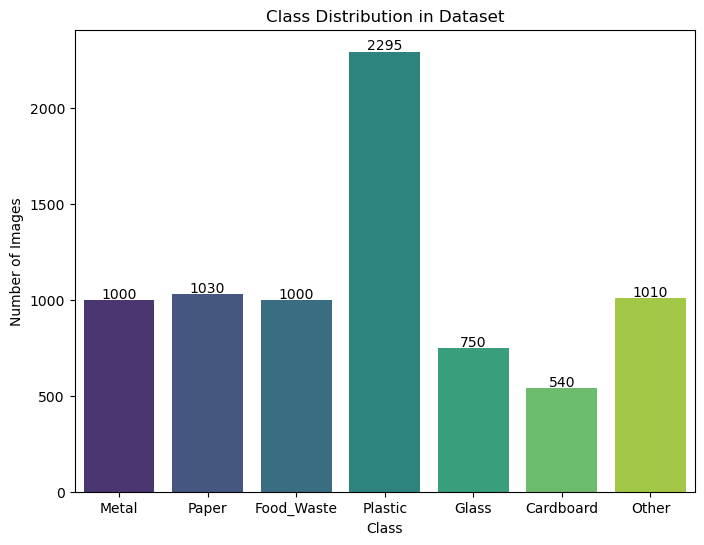

In [49]:
# Visualise Data Distribution

# Prepare data for plotting
labels_list = [class_names[i] for i in counts.keys()]
counts_list = [counts[i] for i in counts.keys()]

# Plot with Seaborn + Matplotlib
plt.figure(figsize=(8, 6))
sns.barplot(x=labels_list, y=counts_list, palette="viridis")

# Add labels and title
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Dataset")

# Show counts on top of bars
for i, count in enumerate(counts_list):
    plt.text(i, count + 10, str(count), ha='center')

plt.show()


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

### ✦ My Analysis
#### Visualise Sample Images 

This function visualizes a configurable number of images from one or more batches, ensuring safe indexing and proper grid layout for clear data inspection.

In [75]:
def visualise_sample_images(dataset, batch_size: int = 1, range_val: int = 12, dataset_name=''):
    if batch_size <= 0:
        raise ValueError("batch_size must be greater than 0")
    if range_val <= 0:
        raise ValueError("range_val must be greater than 0")
    
    dataset_label = f"Visualizing {dataset_name} Dataset" if dataset_name else "Visualizing Dataset"
    print("\n" + "="*80)
    print(f"             📊 {dataset_label}")
    print("="*80 + "\n")
    
    for images, labels in dataset.take(batch_size):
        plt.figure(figsize=(12, 12))
        
        cols = 3
        rows = (range_val + cols - 1) // cols

        num_images = min(range_val, images.shape[0])

        for i in range(num_images):
            ax = plt.subplot(rows, cols, i + 1)
            img = images[i].numpy()

            # Fix pixel range
            if img.max() > 1:
                img = img / 255.0
                
            plt.imshow(img)
            plt.title(class_names[labels[i].numpy()])
            plt.axis("off")
        
        plt.tight_layout()
        plt.show()


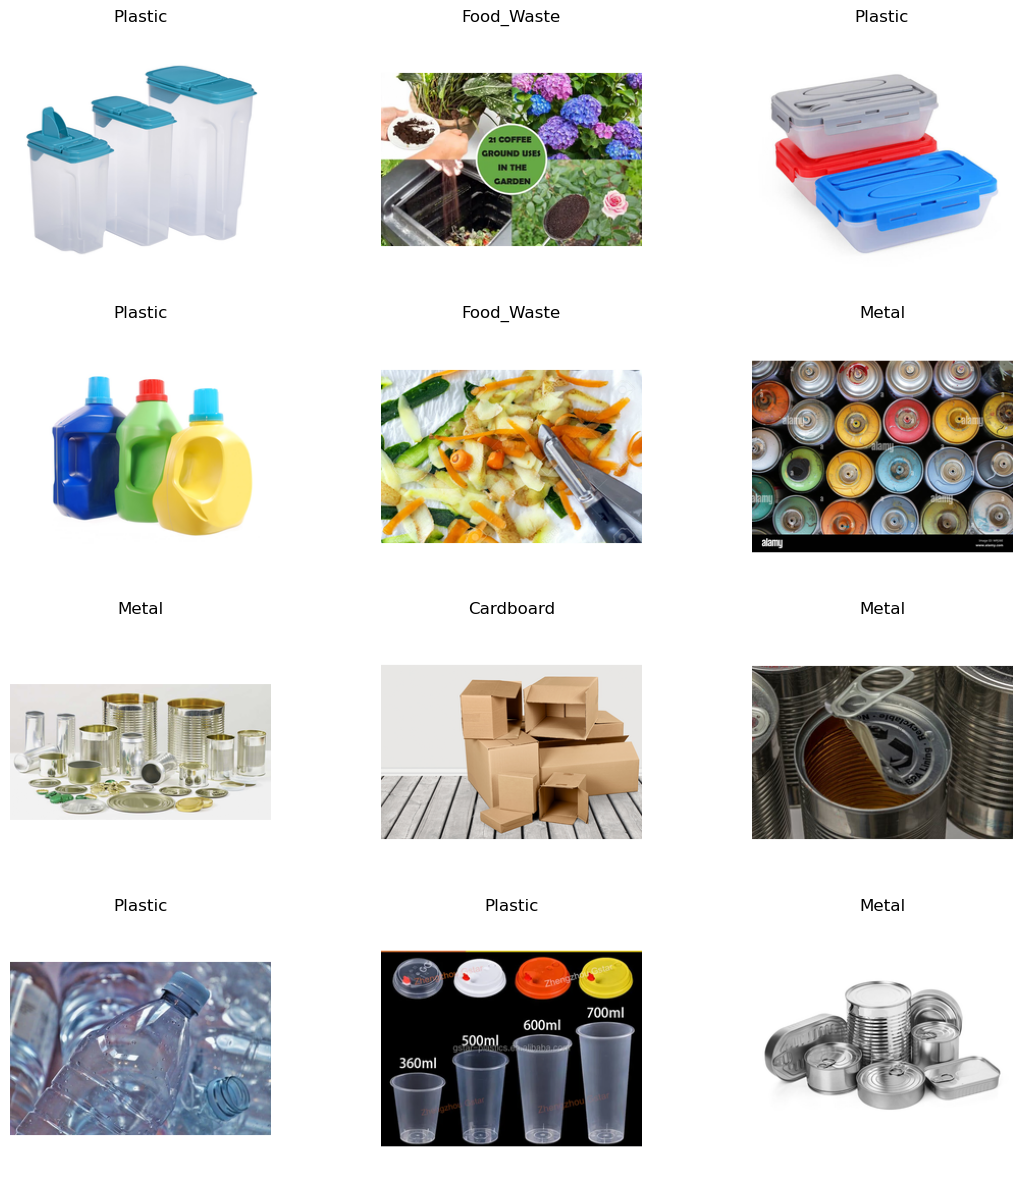

In [51]:
# Visualise Sample Images (across different labels)

visualise_sample_images(dataset=dataset, batch_size=1, range_val=12)

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [52]:
#Function to get the smallest and largest dimension
from typing import Tuple

def get_smallest_largest_dimension(batch_size: int = 5) -> Tuple[int, int, int, int]:
    min_h, min_w = float('inf'), float('inf')
    max_h, max_w = 0, 0

    for images, _ in dataset.take(batch_size):  # sample some batches
        for img in images:
            h, w = img.shape[0], img.shape[1]
            min_h, min_w = min(min_h, h), min(min_w, w)
            max_h, max_w = max(max_h, h), max(max_w, w)
    
    if min_h == float('inf'):
        raise ValueError("Dataset is empty or batch_size too small")
    
    return min_h, min_w, max_h, max_w



In [53]:
# Find the smallest and largest image dimensions from the data set
min_h, min_w, max_h, max_w = get_smallest_largest_dimension(batch_size=10)
print("Smallest Image:", (min_h, min_w))
print("Largest Image:", (max_h, max_w))


Smallest Image: (256, 256)
Largest Image: (256, 256)


### ✦ My Analysis
#### Image Resizing Decision

The dataset analysis showed that both the smallest and largest images were **256 × 256**, indicating uniform dimensions.  
Since resizing was required as part of the assignment, we chose **128 × 128** to balance **computational efficiency** with **image detail**.

---

#### Data Pipeline Optimization

To improve performance during preprocessing, I used:

```python
num_parallel_calls = tf.data.AUTOTUNE

In [54]:
# Resize the image dimensions
def resize_images(image, label, target_size=(128, 128)):
    image = tf.image.resize(image, target_size)
    
    # Normalize only if values are >1
    if tf.reduce_max(image) > 1:
        image = image / 255.0
    return image, label

dataset = dataset.map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)


In [55]:
#Show images and labels after resize
show_images_labels()

Image 0: Shape (128, 128, 3), Label 4 → Other
Image 1: Shape (128, 128, 3), Label 6 → Plastic
Image 2: Shape (128, 128, 3), Label 6 → Plastic
Image 3: Shape (128, 128, 3), Label 6 → Plastic
Image 4: Shape (128, 128, 3), Label 3 → Metal
Image 5: Shape (128, 128, 3), Label 1 → Food_Waste
Image 6: Shape (128, 128, 3), Label 1 → Food_Waste
Image 7: Shape (128, 128, 3), Label 0 → Cardboard
Image 8: Shape (128, 128, 3), Label 6 → Plastic
Image 9: Shape (128, 128, 3), Label 1 → Food_Waste
Image 10: Shape (128, 128, 3), Label 2 → Glass
Image 11: Shape (128, 128, 3), Label 6 → Plastic
Image 12: Shape (128, 128, 3), Label 6 → Plastic
Image 13: Shape (128, 128, 3), Label 6 → Plastic
Image 14: Shape (128, 128, 3), Label 5 → Paper
Image 15: Shape (128, 128, 3), Label 5 → Paper
Image 16: Shape (128, 128, 3), Label 0 → Cardboard
Image 17: Shape (128, 128, 3), Label 6 → Plastic
Image 18: Shape (128, 128, 3), Label 6 → Plastic
Image 19: Shape (128, 128, 3), Label 6 → Plastic
Image 20: Shape (128, 128, 

#### ✦ <i>After resize checking the visualise sample images to verify</i>


             📊 Visualizing Dataset



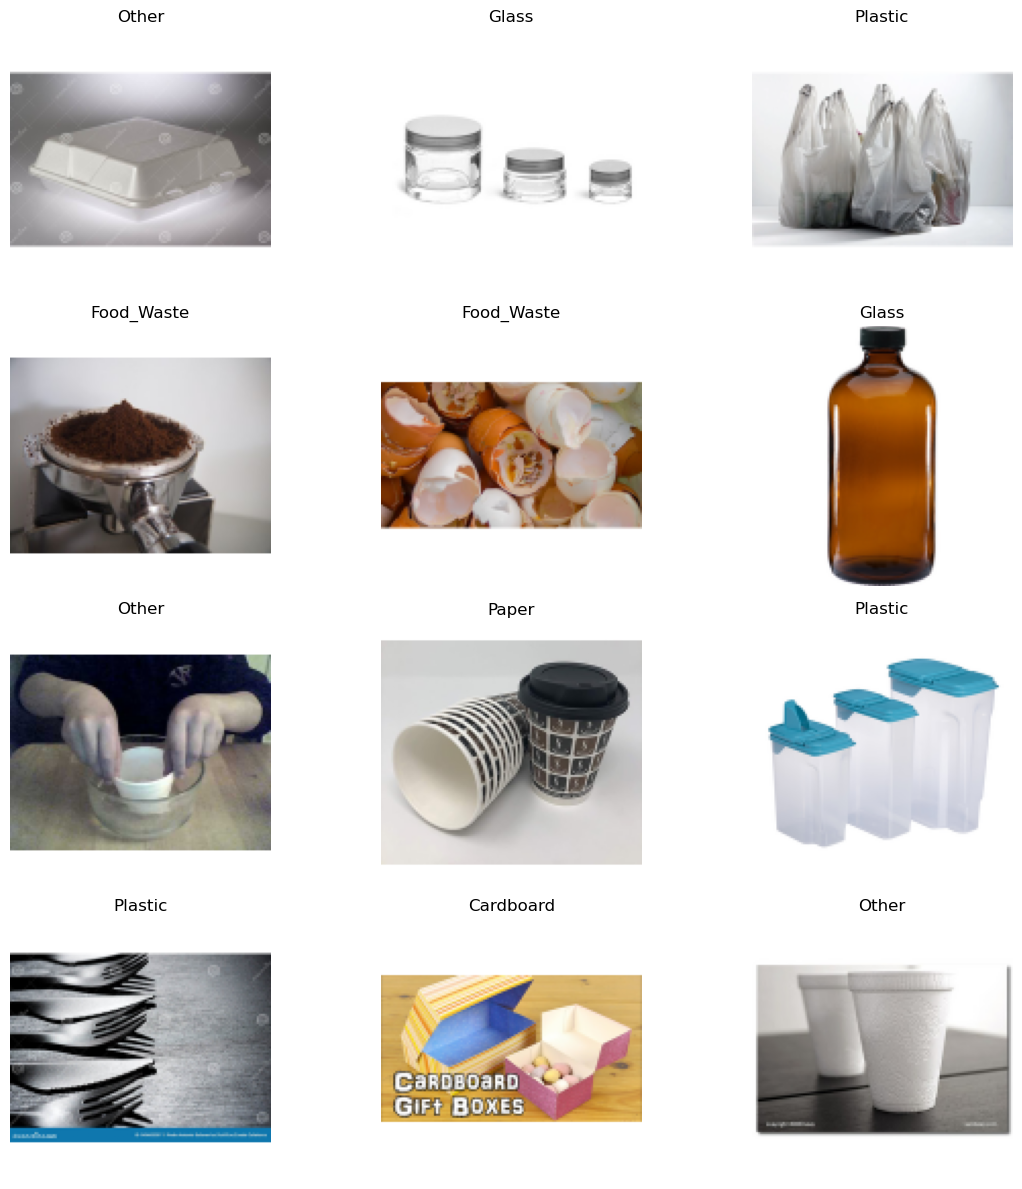

In [76]:
# Visualise Sample Images (across different labels)

visualise_sample_images(dataset=dataset, batch_size=1, range_val=12)

### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

#### **2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

### ✦ My Analysis
#### One Hot Encoding
* Labels are originally integers (0–6)
* Converted into one-hot vectors of size 7
* Ensures compatibility with classification models
> 🟡 **Note:** One-hot encoding is demonstrated on a sample batch for understanding and verification purposes. It has not yet been applied to the entire dataset pipeline.

In [57]:
# Encode the labels suitably
num_classes = 7

# Since labels are integers already (0–6)
for images, labels in dataset.take(1):
    print("Original labels:", labels.numpy())

    # One-hot encode
    one_hot_labels = keras.utils.to_categorical(labels, num_classes)
    print("One-hot encoded labels:\n", one_hot_labels)



Original labels: [6 5 1 4 6 6 5 4 2 5 4 1 1 0 2 6 4 4 2 3 6 6 3 5 4 3 6 5 1 3 6 6]
One-hot encoded labels:
 tf.Tensor(
[[0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1.]], shape=(32, 7), dtype=float32)


### ✦ Color-Based One-Hot Encoding Visualization
#### <i>Interpretation</i>
* If label = 2, only column 2 is highlighted
* If label = 5, only column 5 is highlighted

👉 This visually proves:

“Only one class is active per sample”

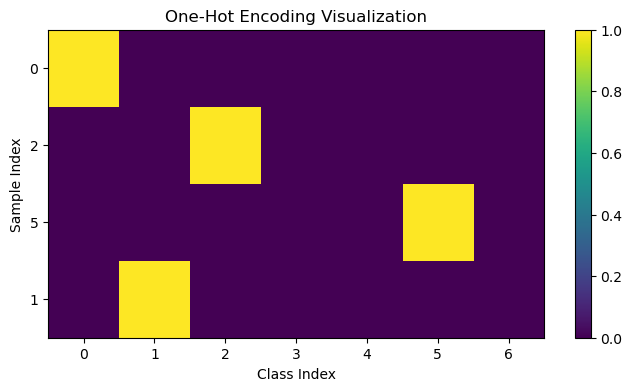

In [58]:
# Sample labels
labels = np.array([0, 2, 5, 1])
num_classes = 7

# One-hot encode
one_hot = keras.utils.to_categorical(labels, num_classes)

# Plot
plt.figure(figsize=(8, 4))
plt.imshow(one_hot, aspect='auto')
plt.colorbar()

# Labels and titles
plt.xlabel("Class Index")
plt.ylabel("Sample Index")
plt.title("One-Hot Encoding Visualization")

# Set ticks
plt.xticks(range(num_classes))
plt.yticks(range(len(labels)), labels)

plt.show()

### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

#### ✦ My Analysis
Using <font color=blue>validation_split</font> within <font color=blue>image_dataset_from_directory</font> is preferred because it splits data at the file level before batching, ensuring better randomness, balanced class distribution, and avoiding batch-level bias.

In [59]:
keras.utils.set_random_seed(42)
# It is used to ensure reproducibility by setting a global seed across TensorFlow, NumPy, and Python’s random module. 
# This helps in generating consistent results across multiple runs.

batch_size = 32
# Number of samples processed in one iteration.
# A batch size of 32 provides a good balance between memory usage and training performance.

image_size = (128, 128)
# Target dimensions for resizing images.
# This size was selected after validating the dataset to ensure consistency and compatibility with the model.

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42, # Controls randomness for dataset splitting and shuffling (local to this dataset)
    batch_size=batch_size,
    image_size=image_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42, # Controls randomness for dataset splitting and shuffling (local to this dataset)
    batch_size=batch_size,
    image_size=image_size
)

Found 7625 files belonging to 7 classes.
Using 6100 files for training.
Found 7625 files belonging to 7 classes.
Using 1525 files for validation.


#### ✦ Helper Class
A helper function is created to inspect the dataset by validating batch sizes, tensor shapes, data types, label samples, and pixel value ranges. This ensures the correctness of the preprocessing pipeline before model training.

In [60]:
def inspect_dataset(train_ds, val_ds):
    # Handle unknown dataset length
    try:
        print("Train batches:", len(train_ds))
    except TypeError:
        print("Train dataset size unknown")

    try:
        print("Validation batches:", len(val_ds))
    except TypeError:
        print("Validation dataset size unknown")

    # Inspect one batch from training dataset
    for images, labels in train_ds.take(1):
        print("\n--- Training Dataset Sample ---")
        print("Image batch shape:", images.shape)
        print("Label batch shape:", labels.shape)
        print("Image dtype:", images.dtype)
        print("Label dtype:", labels.dtype)
        print("Sample labels:", labels[:10].numpy())
        print("Min pixel value:", tf.reduce_min(images).numpy())
        print("Max pixel value:", tf.reduce_max(images).numpy())

    # Inspect one batch from validation dataset
    for images, labels in val_ds.take(1):
        print("\n--- Validation Dataset Sample ---")
        print("Image batch shape:", images.shape)
        print("Label batch shape:", labels.shape)

    # Class names (if available)
    if hasattr(train_ds, "class_names"):
        print("\nClass names:", train_ds.class_names)


Train batches: 191
Validation batches: 48

--- Training Dataset Sample ---
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Sample labels: [4 6 3 6 4 1 6 0 6 1]
Min pixel value: 0.0
Max pixel value: 255.0

--- Validation Dataset Sample ---
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)

Class names: ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']

             📊 Visualizing Training Dataset



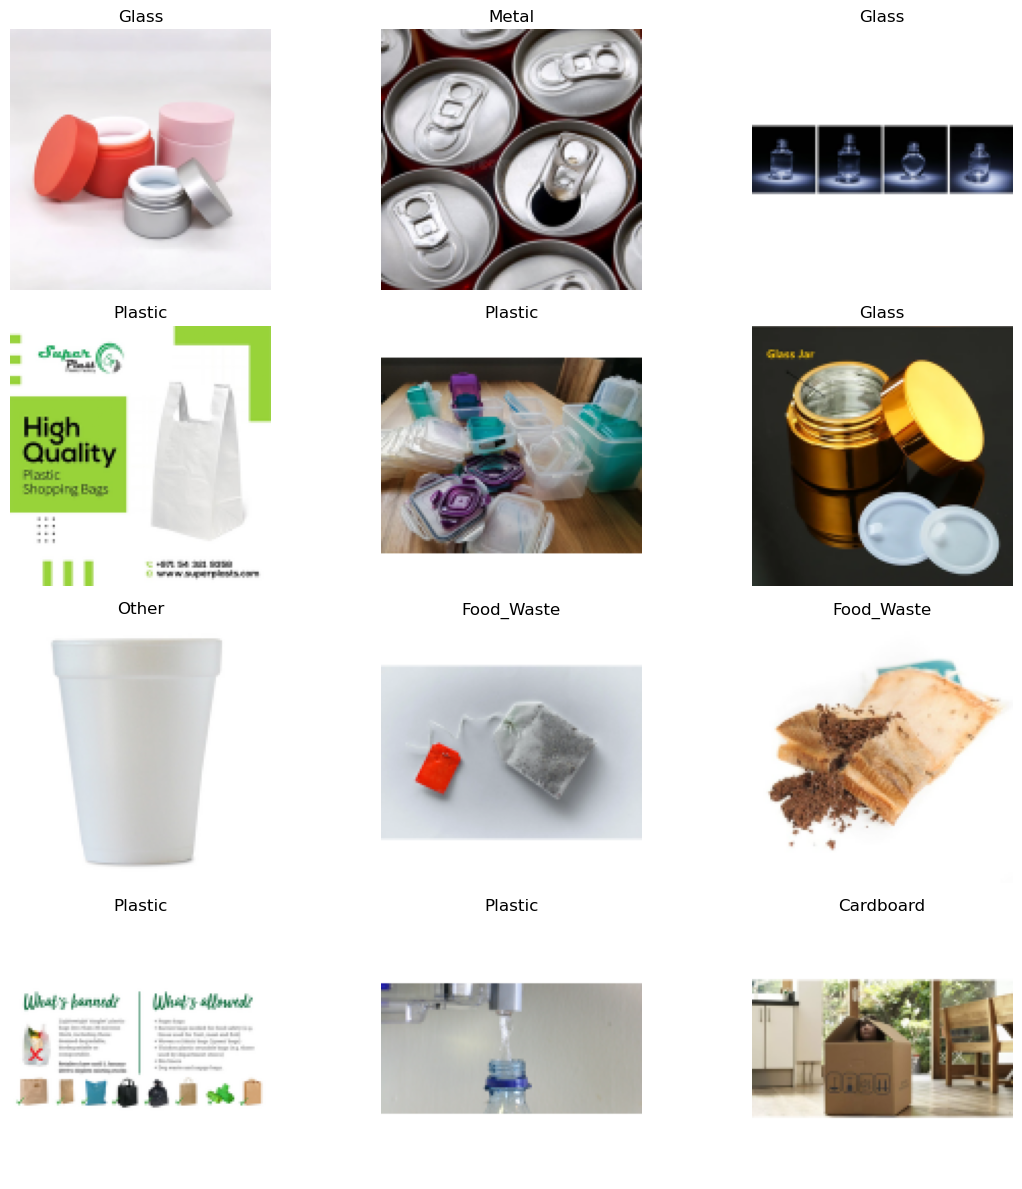


             📊 Visualizing Testing Dataset



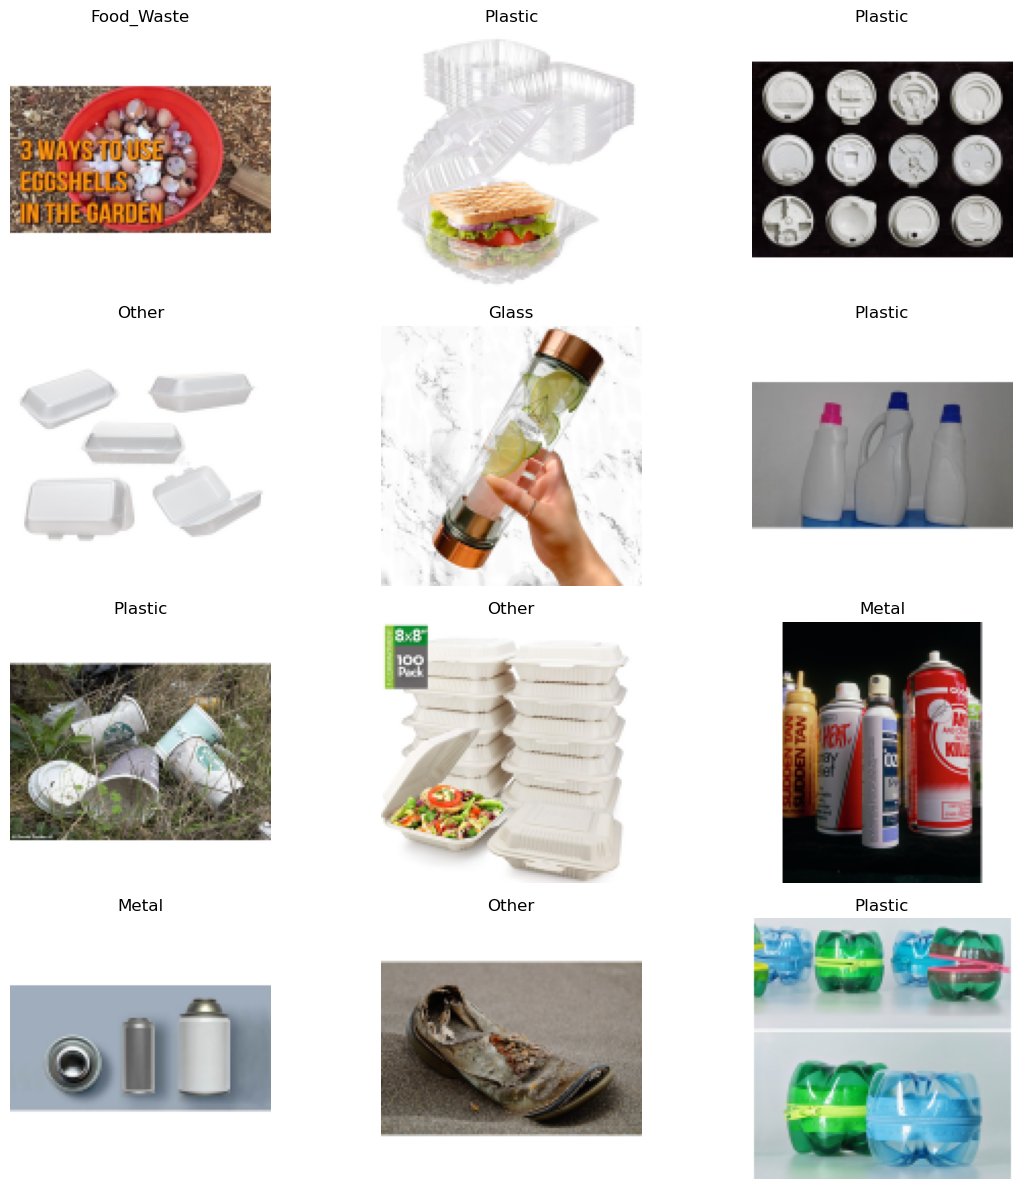

In [77]:
inspect_dataset(train_ds=train_ds, val_ds=val_ds)

# Visualise Training Dataset
visualise_sample_images(dataset= train_ds, batch_size=1, range_val=12, dataset_name="Training")

# Visualise Testing Dataset
visualise_sample_images(dataset= val_ds, batch_size=1, range_val=12, dataset_name="Testing")

## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

### ✦ Experimental Analysis & Approach

To systematically evaluate the performance of the CNN model, multiple controlled experiments were conducted by varying key architectural and training parameters. The following configurations were tested:

- **Experiment 1:** Model without Batch Normalization  
- **Experiment 2:** Increased Dropout Rate for stronger regularization  
- **Experiment 3:** Replacement of Global Average Pooling with Flatten layer  
- **Experiment 4:** Reduced Learning Rate for stable convergence  

A **modular and scalable approach** was adopted by designing a reusable model-building function. This enabled efficient experimentation by dynamically adjusting parameters such as dropout rate, batch normalization, pooling strategy, and learning rate without redundant code duplication.

This approach ensured:
- **Consistency across experiments** (only one variable changed at a time)
- **Improved code maintainability and readability**
- **Faster experimentation and iteration**

Such a structured methodology aligns with best practices in deep learning, allowing for reliable comparison and informed decision-making when optimizing model performance.

In [3]:
# Helper function
def build_model(use_batchnorm=True, dropout_rate=0.25, use_gap=True, lr=1e-3):
    model = keras.Sequential([
        keras.Input(shape=(32, 32, 3)),

        # Block 1
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        *( [layers.BatchNormalization()] if use_batchnorm else [] ),
        layers.MaxPooling2D(),
        layers.Dropout(dropout_rate),

        # Block 2
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        *( [layers.BatchNormalization()] if use_batchnorm else [] ),
        layers.MaxPooling2D(),
        layers.Dropout(dropout_rate),

        # Block 3
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        *( [layers.BatchNormalization()] if use_batchnorm else [] ),

        # Pooling choice
        layers.GlobalAveragePooling2D() if use_gap else layers.Flatten(),

        # Dense
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

> ✦ **Note:** The `run_experiment` function standardizes the training and evaluation workflow, enabling controlled experimentation by isolating variable parameters. This ensures fair comparison between model configurations, promotes reproducibility, and follows best practices for systematic hyperparameter tuning.

In [1]:
def run_experiment(name, **params):
    print(f"\nRunning: {name}")

    model = build_model(**params)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        verbose=1
    )

    val_acc = max(history.history['val_accuracy'])
    print(f"{name} Best Val Accuracy: {val_acc:.4f}")

    return val_acc

In [ ]:
results = {}

results["Base Model"] = run_experiment(
    "Base Model",
    use_batchnorm=True,
    dropout_rate=0.25,
    use_gap=True,
    lr=1e-3
)

results["No BatchNorm"] = run_experiment(
    "No BatchNorm",
    use_batchnorm=False
)

results["High Dropout"] = run_experiment(
    "High Dropout",
    dropout_rate=0.5
)

results["Flatten Instead of GAP"] = run_experiment(
    "Flatten Model",
    use_gap=False
)

results["Low LR"] = run_experiment(
    "Low Learning Rate",
    lr=1e-4
)

print("\nFinal Results:", results)

In [ ]:
# # Build and compile the model

# model = keras.Sequential([
#     keras.Input(shape=(32, 32, 3)),    
    
#     # Block 1
    
#     layers.Conv2D(32, 3, padding='same', activation='relu'),
#     layers.BatchNormalization(),
#     layers.Conv2D(32, 3, padding='same', activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Dropout(0.25),
    
#     # Block 2

#     layers.Conv2D(64, 3, padding='same', activation='relu'),
#     layers.BatchNormalization(),
#     layers.Conv2D(64, 3, padding='same', activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Dropout(0.25),

#     # Block 3

#     layers.Conv2D(128, 3, padding='same', activation='relu'),
#     layers.BatchNormalization(),
#     layers.GlobalAveragePooling2D(),

#     # Fully connected layers

#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.4),
#     layers.Dense(10, activation='softmax'),
# ])

# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-3),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy'],
# )

# model.summary()


#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [63]:
# Training



### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

In [64]:
# Evaluate on the test set; display suitable metrics



## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [65]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [66]:
# Create a function to augment the images




In [67]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [68]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results